In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("Reviews.csv")

print(df.shape)
df.head()

(568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
df = df[["Score", "Summary", "Text"]]


In [4]:
df = df.dropna()

print(df.shape)

(568427, 3)


In [5]:
df = df[df["Score"] != 3]

df["sentiment"] = df["Score"].apply(lambda x: 1 if x >= 4 else 0)

df.head()

,Score,Summary,Text,sentiment
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,1
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0
2,4,"""Delight"" says it all",This is a confection that has been around a fe...,1
3,2,Cough Medicine,If you are looking for the secret ingredient i...,0
4,5,Great taffy,Great taffy at a great price. There was a wid...,1


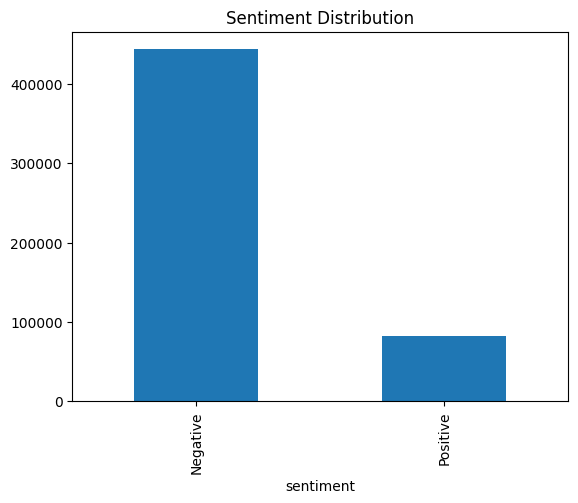

In [6]:
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xticks([0,1], ["Negative", "Positive"])
plt.show()

In [7]:
print(df["sentiment"].value_counts())


sentiment
1    443777
0     82012
Name: count, dtype: int64


In [8]:
df["review"] = df["Summary"] + " " + df["Text"]

df["review_length"] = df["review"].apply(lambda x: len(x.split()))

df["review_length"].describe()

count    525789.000000
mean         83.080163
std          79.237584
min           4.000000
25%          37.000000
50%          59.000000
75%         100.000000
max        2526.000000
Name: review_length, dtype: float64

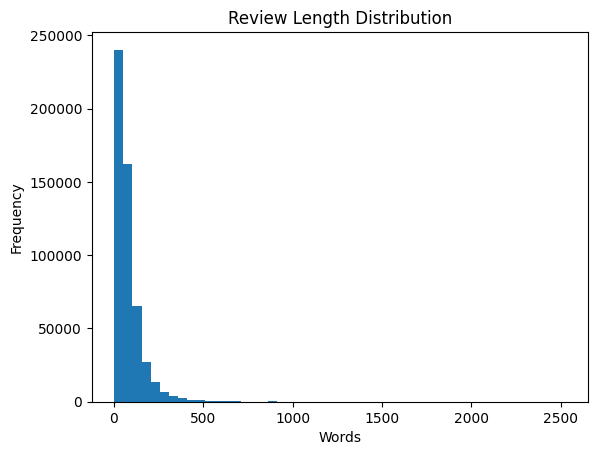

In [9]:
plt.hist(df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [10]:
#%pip install nltk

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Fiki\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Fiki\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Fiki\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [11]:
import re
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

def clean_text_from_stopwords(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)
df["clean_review_no_stopwords"] = df["review"].apply(clean_text_from_stopwords)

In [12]:
df[["review","clean_review", "clean_review_no_stopwords"]].head()

,review,clean_review,clean_review_no_stopwords
0,Good Quality Dog Food I have bought several of...,good quality dog food i have bought several of...,good quality dog food bought several vitality ...
1,Not as Advertised Product arrived labeled as J...,not a advertised product arrived labeled a jum...,advertised product arrived labeled jumbo salte...
2,"""Delight"" says it all This is a confection tha...",delight say it all this is a confection that h...,delight says confection around centuries light...
3,Cough Medicine If you are looking for the secr...,cough medicine if you are looking for the secr...,cough medicine looking secret ingredient robit...
4,Great taffy Great taffy at a great price. The...,great taffy great taffy at a great price there...,great taffy great taffy great price wide assor...


In [13]:
df = df.sample(80000, random_state=42)

print(df.shape)

(80000, 8)


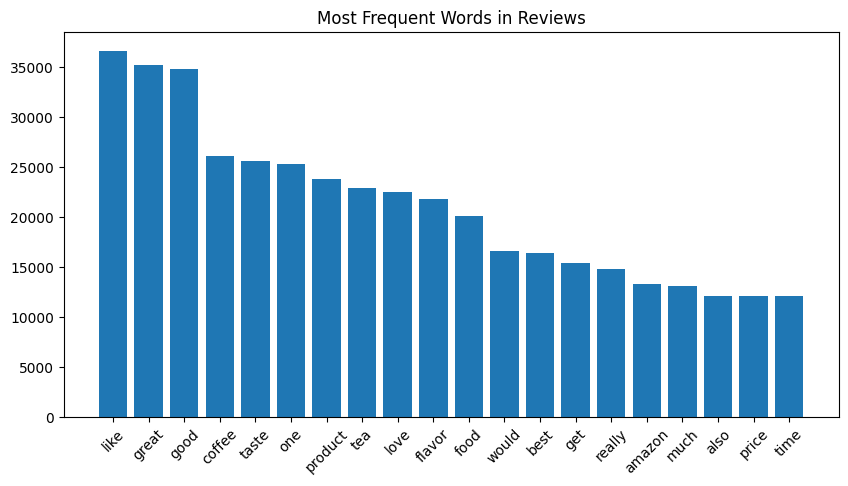

In [14]:
from collections import Counter

all_words = " ".join(df["clean_review_no_stopwords"]).split()

word_counts = Counter(all_words)

common_words = word_counts.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Most Frequent Words in Reviews")
plt.show()

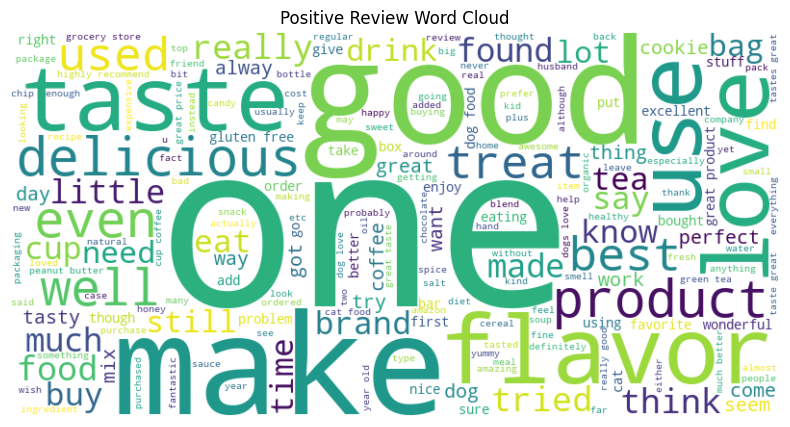

In [15]:
#%pip install wordcloud
from wordcloud import WordCloud

positive_text = " ".join(df[df["sentiment"]==1]["clean_review_no_stopwords"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Review Word Cloud")
plt.show()

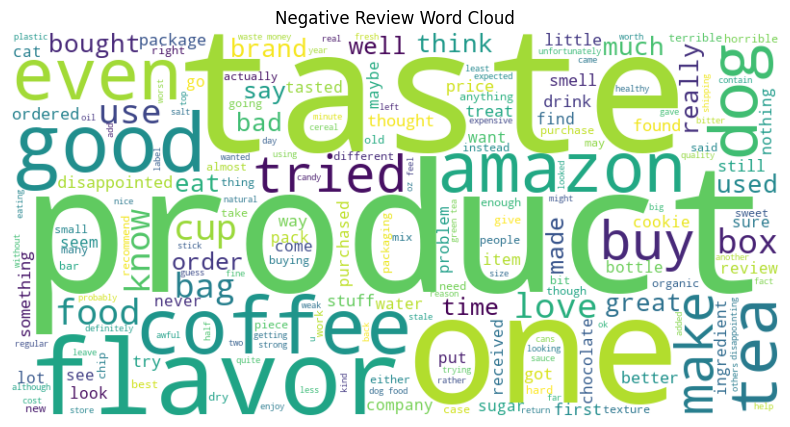

In [16]:
negative_text = " ".join(df[df["sentiment"]==0]["clean_review_no_stopwords"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Review Word Cloud")
plt.show()

In [17]:
positive_words = " ".join(df[df["sentiment"]==1]["clean_review_no_stopwords"]).split()
negative_words = " ".join(df[df["sentiment"]==0]["clean_review_no_stopwords"]).split()

pos_counts = Counter(positive_words)
neg_counts = Counter(negative_words)

top_pos = pos_counts.most_common(15)
top_neg = neg_counts.most_common(15)

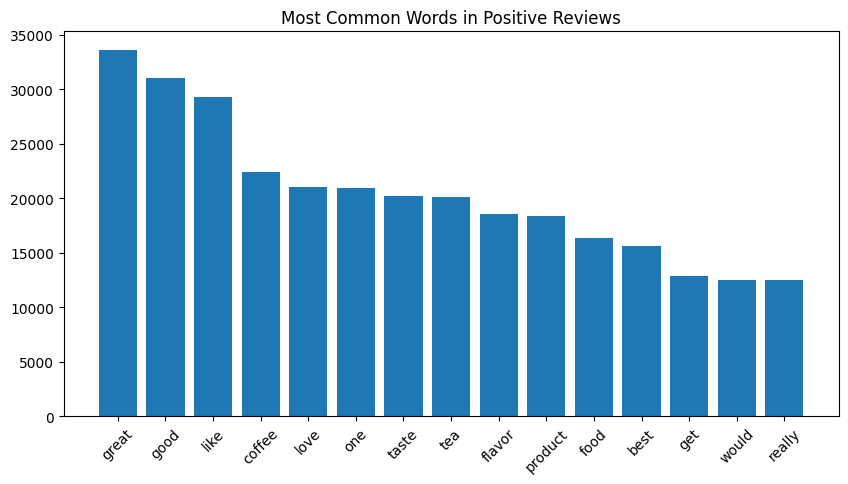

In [18]:
words = [w[0] for w in top_pos]
counts = [w[1] for w in top_pos]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Most Common Words in Positive Reviews")
plt.xticks(rotation=45)
plt.show()

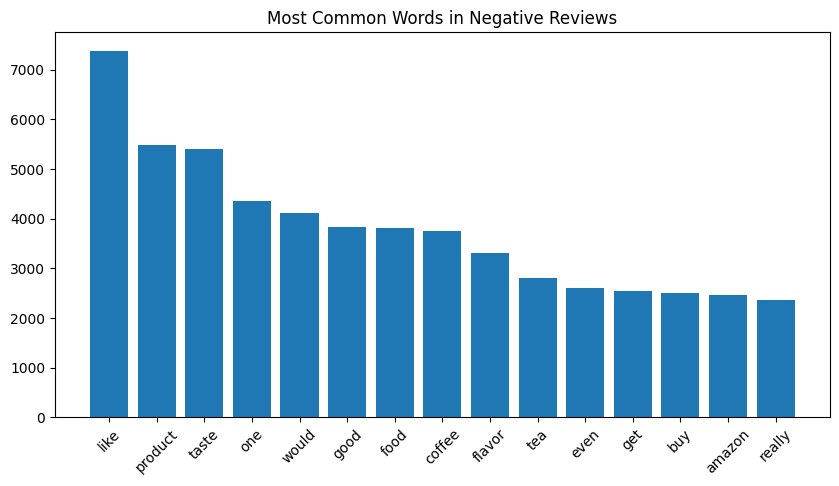

In [19]:
words = [w[0] for w in top_neg]
counts = [w[1] for w in top_neg]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Most Common Words in Negative Reviews")
plt.xticks(rotation=45)
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 64000
Test size: 16000


In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000
MAX_LENGTH = 200

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding="post")

print(X_train_pad.shape)

c:\Users\Fiki\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


(64000, 200)


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Dense, Dropout, LSTM, Bidirectional,
    GlobalAveragePooling1D, Conv1D, GlobalMaxPooling1D
)

model_BiLSTM = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LENGTH),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])


model_BiLSTM_dropout = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LENGTH),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_dense = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LENGTH),
    GlobalAveragePooling1D(),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_LSTM = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LENGTH),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_CNN = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LENGTH),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

models = {
    "BiLSTM": model_BiLSTM,
    "BiLSTM_dropout": model_BiLSTM_dropout,
    "Dense": model_dense,
    "LSTM": model_LSTM,
    "CNN": model_CNN

}

for name, model in models.items():
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

for name, model in models.items():
    print(f"Model ---- {name} ----")
    model.summary()

Model ---- BiLSTM ----


c:\Users\Fiki\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = []
for name, model in models.items():
    print(f"--- {name} ---")
    history_mod = model.fit(
        X_train_pad,
        y_train,
        epochs=5,
        batch_size=64,
        validation_split=0.1
    )
    history.append([name, history_mod])

--- BiLSTM ---
Epoch 1/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 52s 57ms/step - accuracy: 0.9373 - loss: 0.1632 - val_accuracy: 0.9408 - val_loss: 0.1419
Epoch 2/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 51s 56ms/step - accuracy: 0.9617 - loss: 0.1036 - val_accuracy: 0.9461 - val_loss: 0.1347
Epoch 3/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 51s 57ms/step - accuracy: 0.9753 - loss: 0.0712 - val_accuracy: 0.9459 - val_loss: 0.1483
Epoch 4/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 54s 60ms/step - accuracy: 0.9818 - loss: 0.0530 - val_accuracy: 0.9469 - val_loss: 0.1839
Epoch 5/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 60s 67ms/step - accuracy: 0.9880 - loss: 0.0370 - val_accuracy: 0.9508 - val_loss: 0.1930
--- BiLSTM_dropout ---
Epoch 1/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - accuracy: 0.9202 - loss: 0.2020 - val_accuracy: 0.9397 - val_loss: 0.1627
Epoch 2/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 58s 65ms/step - accuracy: 0.9514 - loss: 0.1304 - val_accuracy: 0.9400 - val_loss: 0.1561
Epoch 3/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 59s 65ms/step - accu

In [29]:
def predict_sentiment(model, text):
    
    text = clean_text(text)
    
    seq = tokenizer.texts_to_sequences([text])
    
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding="post")
    
    prob = model.predict(padded, verbose=0)[0][0]
    
    sentiment = "Positive" if prob > 0.5 else "Negative"
    
    return {
        "review": text,
        "sentiment": sentiment,
        "positive_probability": float(prob)
    }

In [30]:
examples = [
    "Absolutely fantastic flavor, will buy again!",
    "Worst product I have ever bought.",
    "Pretty good but a bit expensive.",
    "Completely awful taste.",
    "I like the flavor, but there are better ones.",
     "It is ok.",
    "It is mediocre, youn can find better"
]

for name, model in models.items():
    print(f"--- {name} ---")
    for e in examples:
        print(predict_sentiment(model, e))



--- BiLSTM ---
{'review': 'absolutely fantastic flavor will buy again', 'sentiment': 'Positive', 'positive_probability': 0.9999964833259583}
{'review': 'worst product i have ever bought', 'sentiment': 'Negative', 'positive_probability': 0.0035911803133785725}
{'review': 'pretty good but a bit expensive', 'sentiment': 'Positive', 'positive_probability': 0.9996417760848999}
{'review': 'completely awful taste', 'sentiment': 'Negative', 'positive_probability': 0.003290025517344475}
{'review': 'i like the flavor but there are better one', 'sentiment': 'Positive', 'positive_probability': 0.8023227453231812}
{'review': 'it is ok', 'sentiment': 'Negative', 'positive_probability': 0.4203093349933624}
{'review': 'it is mediocre youn can find better', 'sentiment': 'Negative', 'positive_probability': 0.12980663776397705}
--- BiLSTM_dropout ---
{'review': 'absolutely fantastic flavor will buy again', 'sentiment': 'Positive', 'positive_probability': 0.9999769926071167}
{'review': 'worst product i ha

--- BiLSTM ---
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step
              precision    recall  f1-score   support

           0       0.90      0.78      0.84      2467
           1       0.96      0.99      0.97     13533

    accuracy                           0.95     16000
   macro avg       0.93      0.88      0.90     16000
weighted avg       0.95      0.95      0.95     16000



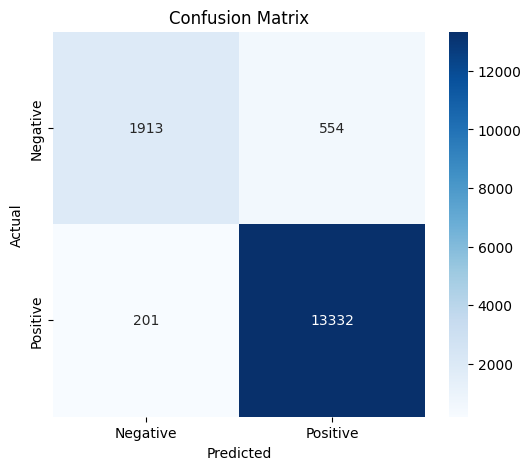

--- BiLSTM_dropout ---
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
              precision    recall  f1-score   support

           0       0.89      0.79      0.83      2467
           1       0.96      0.98      0.97     13533

    accuracy                           0.95     16000
   macro avg       0.92      0.88      0.90     16000
weighted avg       0.95      0.95      0.95     16000



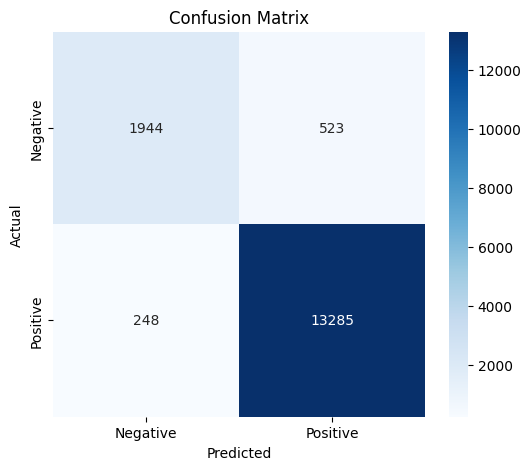

--- Dense ---
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step
              precision    recall  f1-score   support

           0       0.87      0.71      0.78      2467
           1       0.95      0.98      0.96     13533

    accuracy                           0.94     16000
   macro avg       0.91      0.84      0.87     16000
weighted avg       0.94      0.94      0.94     16000



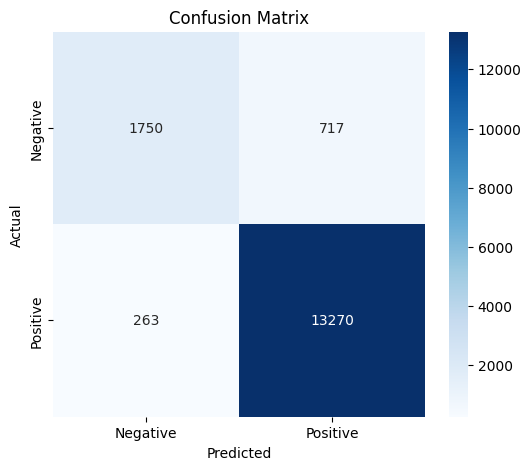

--- LSTM ---
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
              precision    recall  f1-score   support

           0       0.86      0.78      0.82      2467
           1       0.96      0.98      0.97     13533

    accuracy                           0.95     16000
   macro avg       0.91      0.88      0.89     16000
weighted avg       0.94      0.95      0.94     16000



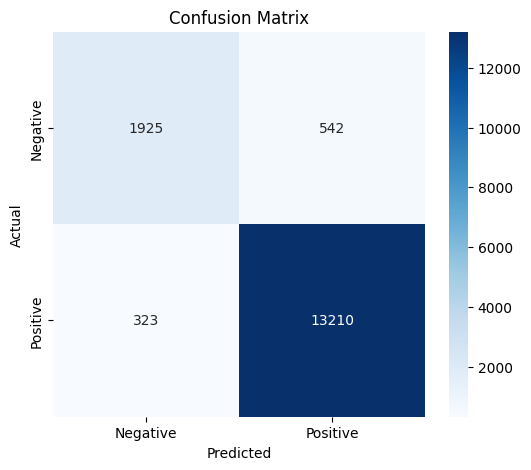

--- CNN ---
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      2467
           1       0.96      0.98      0.97     13533

    accuracy                           0.95     16000
   macro avg       0.92      0.88      0.90     16000
weighted avg       0.95      0.95      0.95     16000



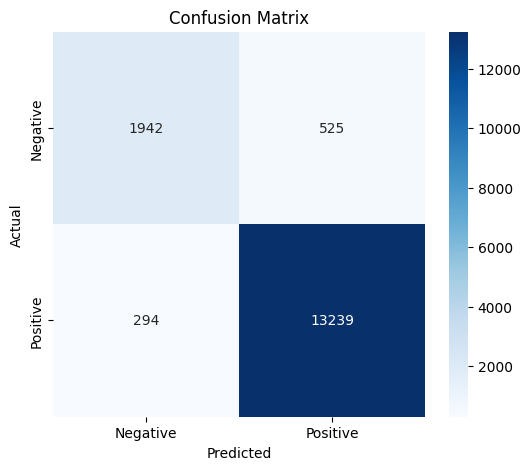

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    print(f"--- {name} ---")
    pred_probs = model.predict(X_test_pad)
    pred_labels = (pred_probs > 0.5).astype(int)

    print(classification_report(y_test, pred_labels))

    cm = confusion_matrix(y_test, pred_labels)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative","Positive"],
                yticklabels=["Negative","Positive"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

--- BiLSTM ---


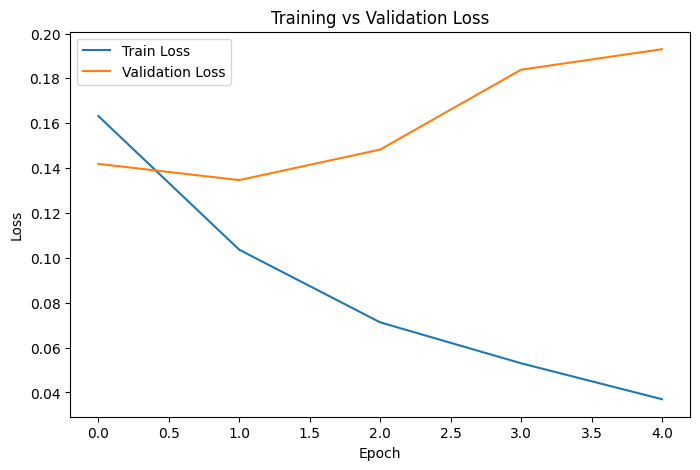

--- BiLSTM_dropout ---


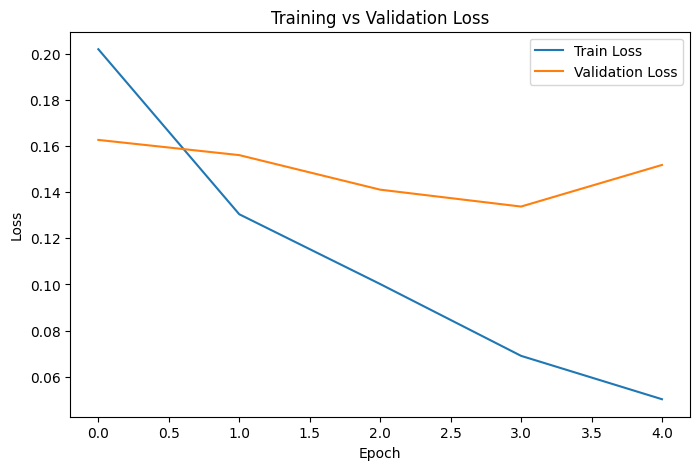

--- Dense ---


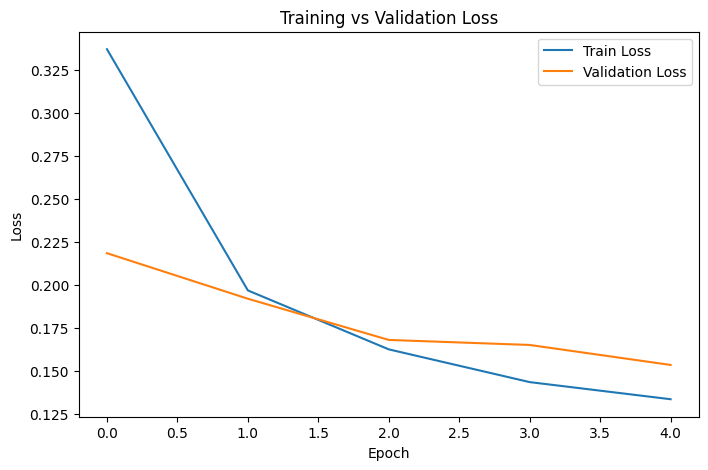

--- LSTM ---


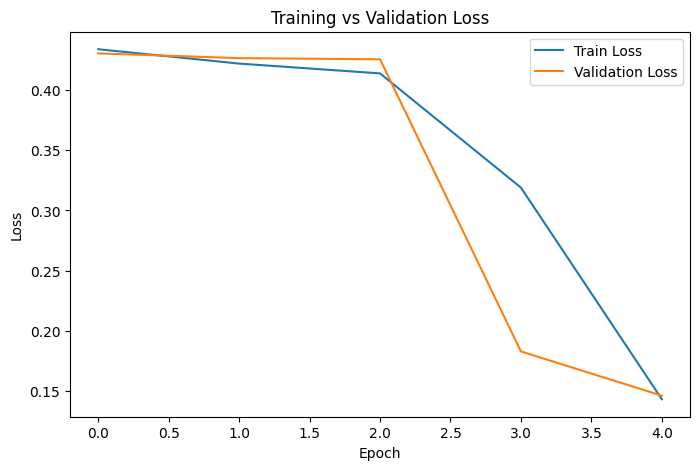

--- CNN ---


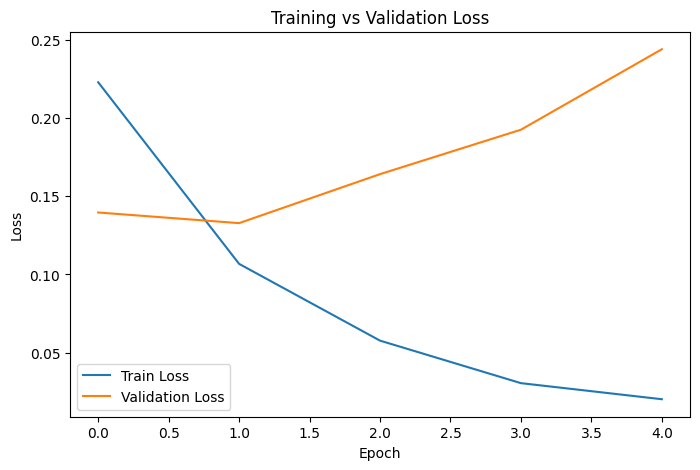

In [32]:
import matplotlib.pyplot as plt

# Loss


for name, hist in history:
    print(f"--- {name} ---")
    plt.figure(figsize=(8,5))
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Validation Loss')
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

--- BiLSTM ---


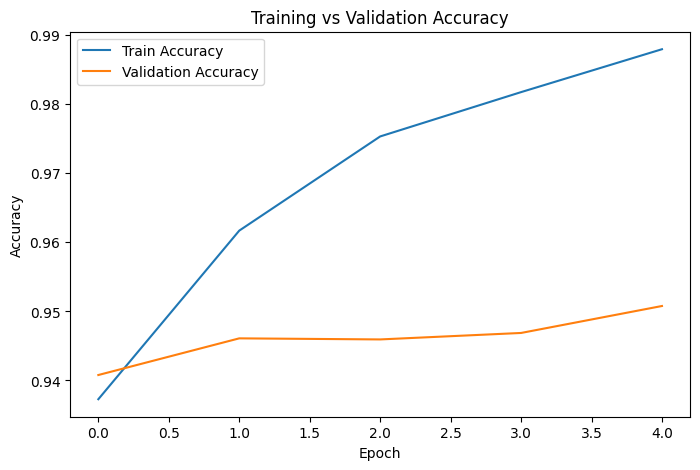

--- BiLSTM_dropout ---


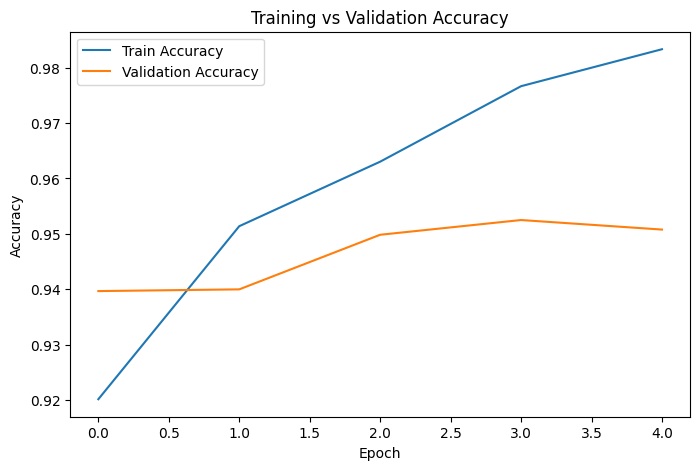

--- Dense ---


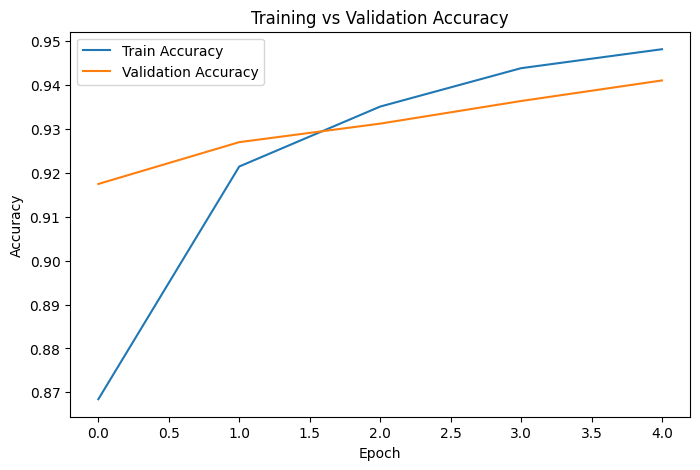

--- LSTM ---


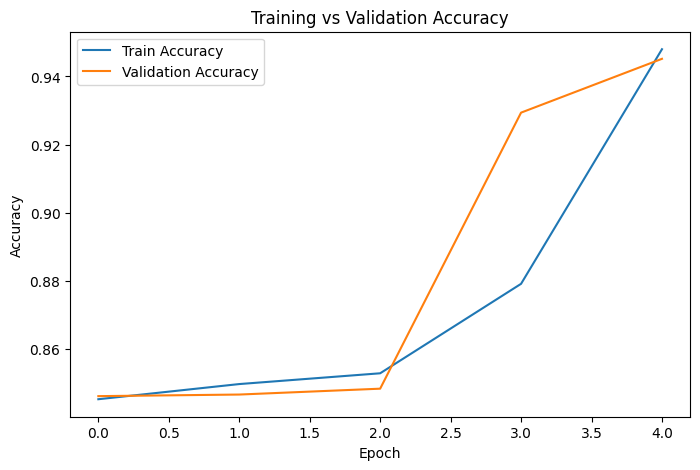

--- CNN ---


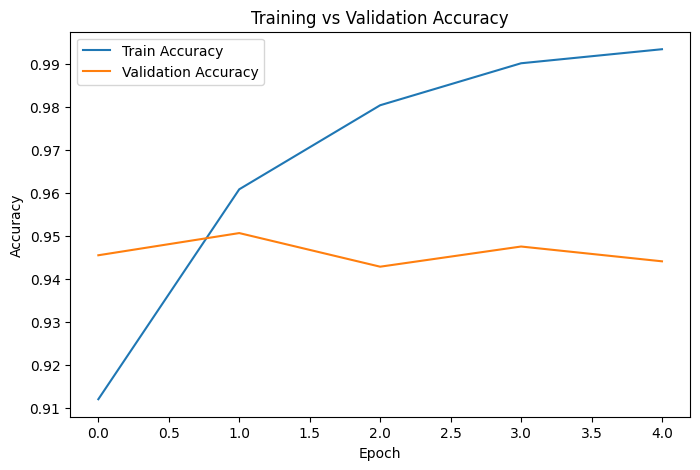

In [33]:
# Accuracy

for name, hist in history:
    print(f"--- {name} ---")
    plt.figure(figsize=(8,5))
    plt.plot(hist.history['accuracy'], label='Train Accuracy')
    plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


In [38]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
print(class_weights)



{np.int64(0): np.float64(3.2424764413821054), np.int64(1): np.float64(0.591158485895328)}


In [43]:
model_BiLSTM = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LENGTH),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])


model_BiLSTM_dropout = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LENGTH),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_dense = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LENGTH),
    GlobalAveragePooling1D(),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_LSTM = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LENGTH),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_CNN = Sequential([
    Embedding(VOCAB_SIZE, 128, input_length=MAX_LENGTH),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

models = {
    "BiLSTM": model_BiLSTM,
    "BiLSTM_dropout": model_BiLSTM_dropout,
    "Dense": model_dense,
    "LSTM": model_LSTM,
    "CNN": model_CNN

}

for name, model in models.items():
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )


history = []
for name, model in models.items():
    print(f"--- {name} ---")
    history_mod = model.fit(
     X_train_pad,
     y_train,
     validation_split=0.1,
     epochs=10,
     batch_size=64,
     callbacks=[early_stop],
     class_weight=class_weights
    )
    history.append([name, history_mod])


--- BiLSTM ---
Epoch 1/10


c:\Users\Fiki\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


900/900 ━━━━━━━━━━━━━━━━━━━━ 51s 55ms/step - accuracy: 0.8670 - loss: 0.3159 - val_accuracy: 0.8692 - val_loss: 0.2833
Epoch 2/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 49s 55ms/step - accuracy: 0.9198 - loss: 0.1908 - val_accuracy: 0.9155 - val_loss: 0.2197
--- BiLSTM_dropout ---
Epoch 1/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 51s 55ms/step - accuracy: 0.8762 - loss: 0.2993 - val_accuracy: 0.9322 - val_loss: 0.1850
Epoch 2/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 49s 55ms/step - accuracy: 0.9365 - loss: 0.1641 - val_accuracy: 0.8988 - val_loss: 0.2820
--- Dense ---
Epoch 1/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7401 - loss: 0.4924 - val_accuracy: 0.8414 - val_loss: 0.3741
Epoch 2/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8832 - loss: 0.2784 - val_accuracy: 0.9266 - val_loss: 0.1916
--- LSTM ---
Epoch 1/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.5590 - loss: 0.6914 - val_accuracy: 0.8303 - val_loss: 0.6926
Epoch 2/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 34s 38ms/step

--- BiLSTM ---
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step
              precision    recall  f1-score   support

           0       0.57      0.89      0.69      2467
           1       0.98      0.88      0.92     13533

    accuracy                           0.88     16000
   macro avg       0.77      0.89      0.81     16000
weighted avg       0.92      0.88      0.89     16000



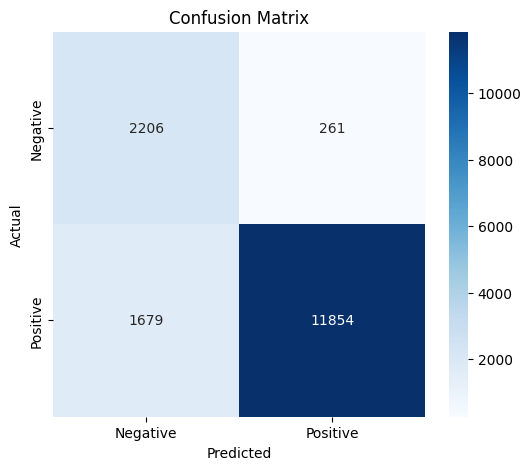

--- BiLSTM_dropout ---
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step
              precision    recall  f1-score   support

           0       0.76      0.86      0.80      2467
           1       0.97      0.95      0.96     13533

    accuracy                           0.94     16000
   macro avg       0.86      0.90      0.88     16000
weighted avg       0.94      0.94      0.94     16000



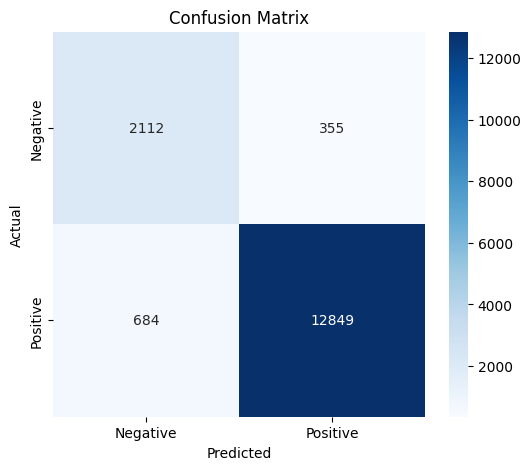

--- Dense ---
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step
              precision    recall  f1-score   support

           0       0.49      0.92      0.64      2467
           1       0.98      0.82      0.90     13533

    accuracy                           0.84     16000
   macro avg       0.73      0.87      0.77     16000
weighted avg       0.91      0.84      0.86     16000



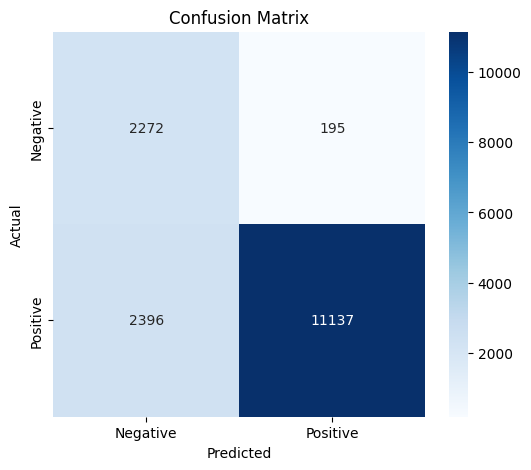

--- LSTM ---
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
              precision    recall  f1-score   support

           0       0.26      0.08      0.12      2467
           1       0.85      0.96      0.90     13533

    accuracy                           0.82     16000
   macro avg       0.56      0.52      0.51     16000
weighted avg       0.76      0.82      0.78     16000



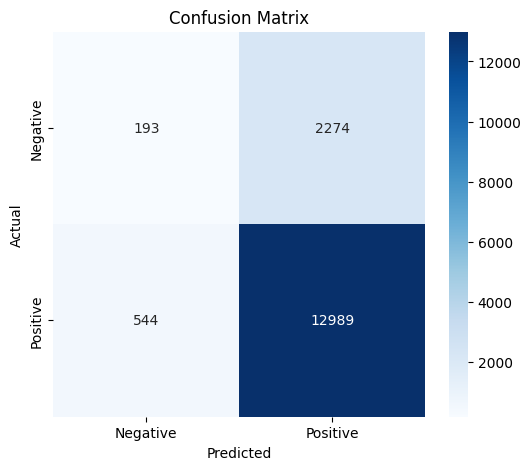

--- CNN ---
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.79      0.87      0.83      2467
           1       0.98      0.96      0.97     13533

    accuracy                           0.94     16000
   macro avg       0.88      0.91      0.90     16000
weighted avg       0.95      0.94      0.94     16000



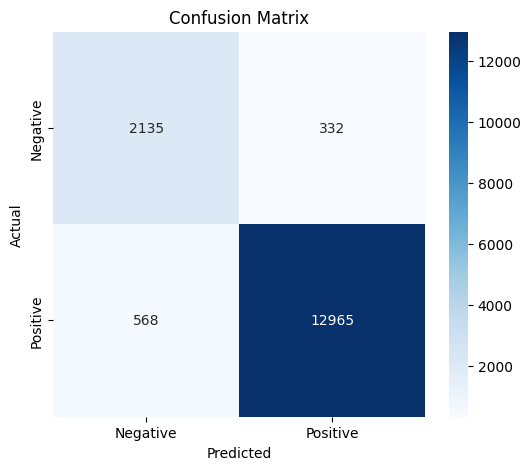

In [44]:
for name, model in models.items():
    print(f"--- {name} ---")
    pred_probs = model.predict(X_test_pad)
    pred_labels = (pred_probs > 0.5).astype(int)

    print(classification_report(y_test, pred_labels))

    cm = confusion_matrix(y_test, pred_labels)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative","Positive"],
                yticklabels=["Negative","Positive"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

--- BiLSTM ---


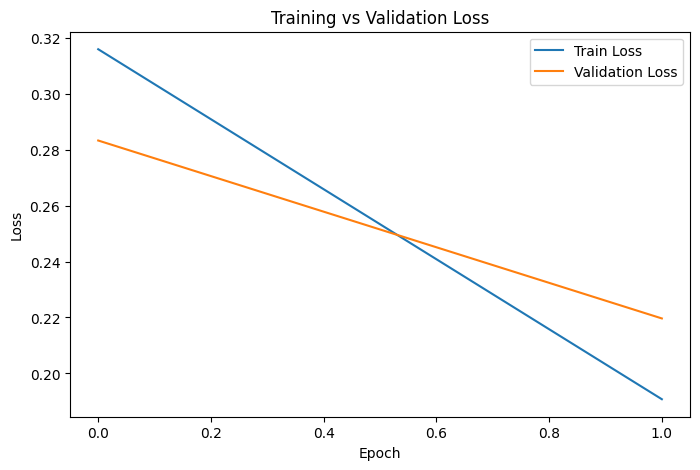

--- BiLSTM_dropout ---


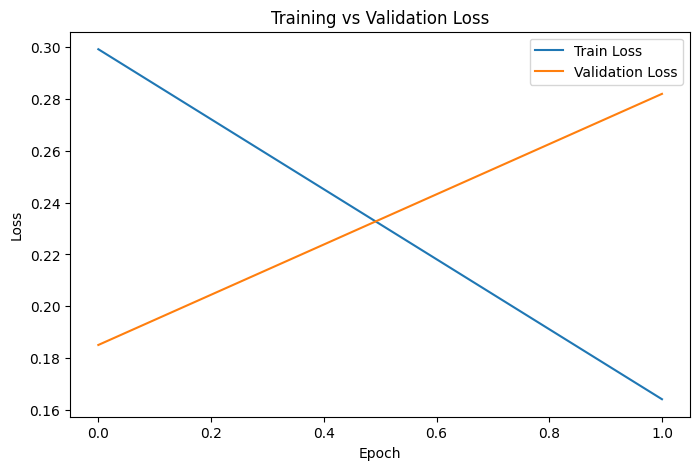

--- Dense ---


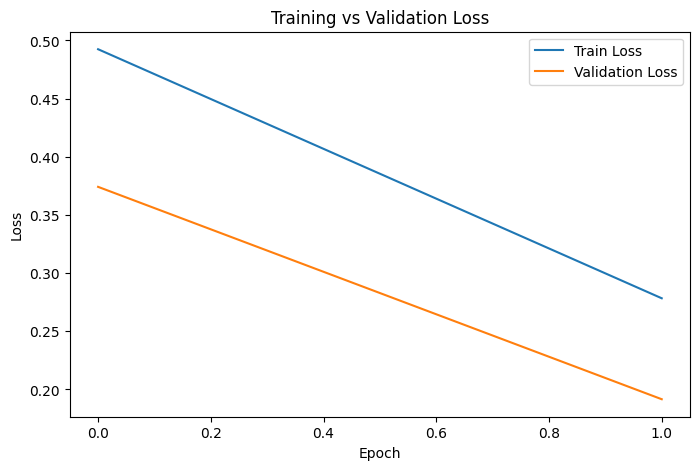

--- LSTM ---


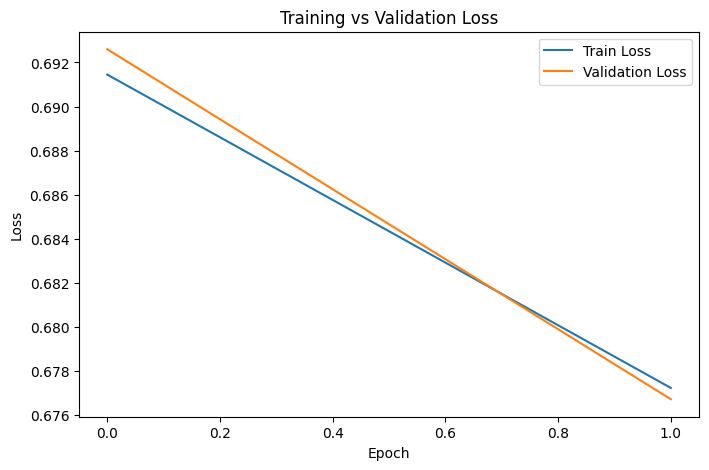

--- CNN ---


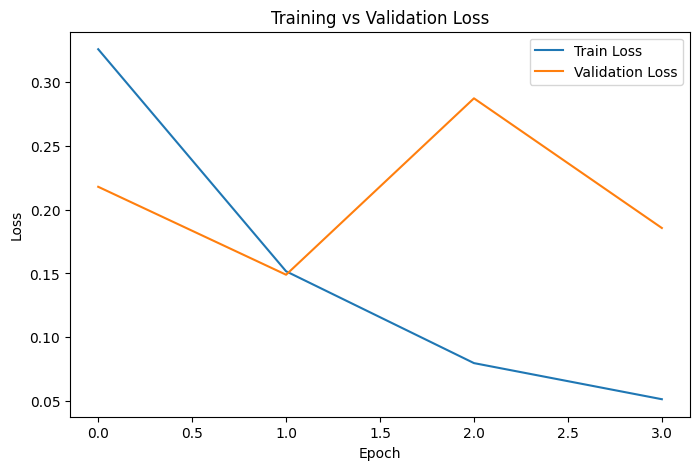

In [47]:
for name, hist in history:
    print(f"--- {name} ---")
    plt.figure(figsize=(8,5))
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Validation Loss')
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

--- BiLSTM ---


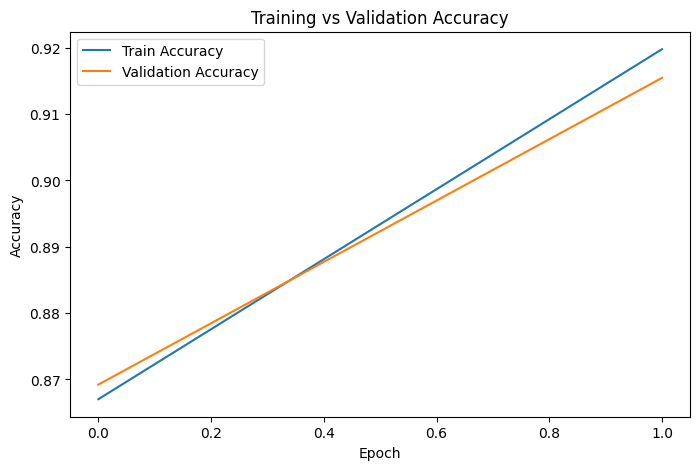

--- BiLSTM_dropout ---


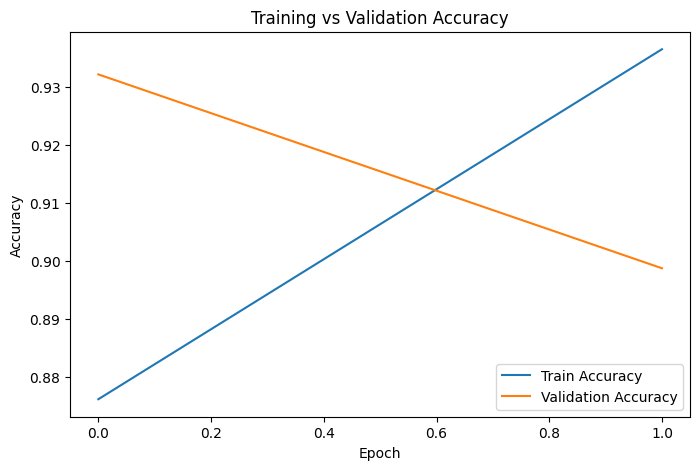

--- Dense ---


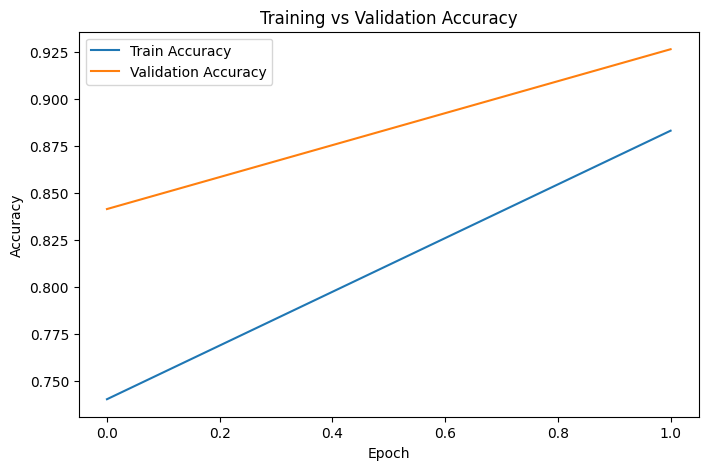

--- LSTM ---


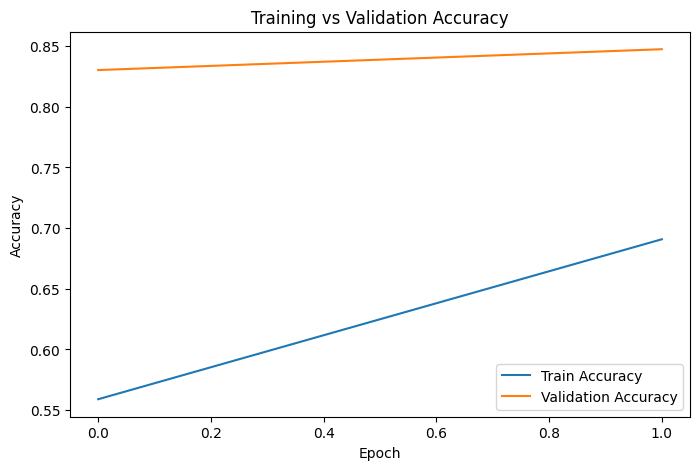

--- CNN ---


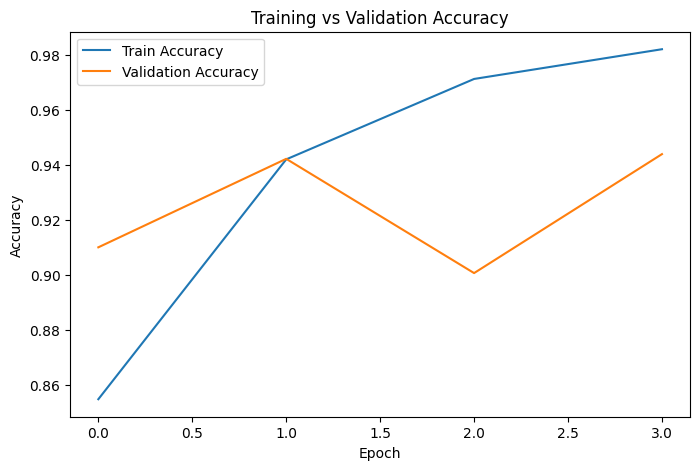

In [48]:
for name, hist in history:
    print(f"--- {name} ---")
    plt.figure(figsize=(8,5))
    plt.plot(hist.history['accuracy'], label='Train Accuracy')
    plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

In [ ]:
#glvoe embeddings

GLOVE_PATH = "glove.6B.100d.txt"

embeddings_index = {}

with open(GLOVE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print("Loaded word vectors:", len(embeddings_index))